In [28]:
import pandas as pd

#load of the dataset
data= pd.read_csv("../../Data/useCarData.csv", sep=";")
#data.info()
print(data.isnull().sum())

Brand and model                          0
Year of manufacture                      0
Mileage                                  0
Engine power (hp)                        0
Fuel type                                0
Transmission type                        0
Trim level / Equipment line              0
Vehicle condition                        0
Origin                                   0
Energy consumption                       0
Power output (kW)                        0
Category / Vehicle type                  0
Engine displacement (cc)                 0
Price (EUR)                              0
Color                                    0
Air conditioning / Climate control       0
Transmission                             0
Number of doors                          0
Number of seats                          0
Drive type                               0
Interior equipment / Interior design     0
Accident history                         0
Number of previous owners                0
Maintenance

## Key Changes
SimpleImputer fills missing values:

strategy='mean' for numeric features (averages the values)
strategy='most_frequent' for categorical features (uses the most common value)
Pipeline nesting ensures imputation happens before encoding/scaling

## Optional: Check for Missing Data First
Add this to diagnose which columns have NaNs:

This shows you the extent of missing values per column, helping you decide if 'mean' imputation makes sense or if you should drop columns/rows instead.


 
--------------------------------------------------
Number of doors
4    62
5    28
3     9
2     1
Name: count, dtype: int64

  
--------------------------------------------------
Vehicle condition
good          39
acceptable    26
very good     25
needs work     6
like new       2
new            2
Name: count, dtype: int64

preprocessor: ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('imputer', SimpleImputer()),
                                                 ('scaler', StandardScaler())]),
                                 ['Year of manufacture', 'Mileage',
                                  'Engine power (hp)', 'Energy consumption',
                                  'Power output (kW)',
                                  'Engine displacement (cc)', 'Number of doors',
                                  'Number of seats',
                                  'Number of previous owners',
                                  'Dealer rating']),
  

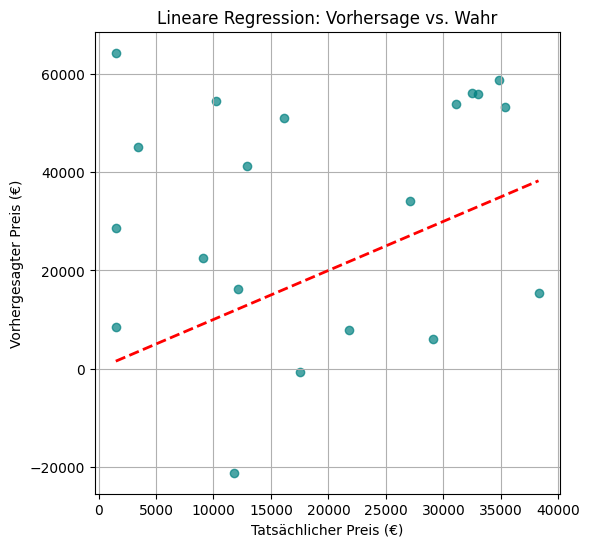

In [9]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

data= pd.read_csv("../../Data/useCarData.csv", sep=";")


#Display the columns of the datasets
#print(data.columns)
print("\n ")
print("-" * 50)
doors_data=data["Number of doors"].value_counts()
print(doors_data)
print("\n  ")
print("-" * 50)
previousOwerns_data=data["Vehicle condition"].value_counts()
print(previousOwerns_data)





#ordinale features
ordinal_features = {
    'Vehicle condition': ['needs work', 'acceptable', 'good', 'very good', 'like new', 'new'],
    'Inspection status (TÜV/HU)': ['Expired', 'Expiring soon', 'Valid TÜV/HU'],
    'Body & paint': ['Poor', 'Fair', 'Good', 'Excellent'],
    'Panel gaps & fit': ['Uneven', 'Slightly uneven', 'Even'],
    'Windows & lights': ['Cracked or yellowed', 'Minor scratches', 'Clear'],
    'Tires & wheels': ['Damaged', 'Uneven wear', 'Even wear', 'New'],
    'Undercarriage & edges': ['Oil stains', 'Water damage', 'Minor rust', 'Clean'],
    'Seats & upholstery': ['Torn', 'Worn', 'Good', 'Excellent'],
    'Dashboard & controls': ['Worn', 'Scratched', 'Good', 'Excellent'],
    'Headliner & carpets': ['Sagging', 'Moisture damage', 'Minor stains', 'Clean'],
    'Trunk': ['Rust', 'Minor stains', 'Clean'],
    'Odor': ['Pet odor', 'Smoke', 'Moisture', 'None']
}

# Nominal features
nominal_features = [
    'Brand and model', 
    'Fuel type',
    'Transmission type', 
    'Trim level / Equipment line', 
    'Origin', 
    'Color',
    'Air conditioning / Climate control', 
    'Transmission',
    'Drive type', 
    'Interior equipment / Interior design',
    'Accident history', 
    'Maintenance / service history', 
    'Region / city',
    'Listing duration',
    'Seller type',
    'Category / Vehicle type'
]

# Numeric features
numeric_features = [
    "Year of manufacture",
    "Mileage",
    "Engine power (hp)",
    "Energy consumption",
    "Power output (kW)",
    "Engine displacement (cc)",
    "Number of doors",
    "Number of seats",
    "Number of previous owners",
   # "Sale price",
    "Dealer rating",
]

# Function to process Extras column
def process_extras(extras_series):
    """Convertit la colonne Extras en variables binaires"""
    all_extras = set()
    for extras_list in extras_series.dropna():
        for extra in extras_list.split(', '):
            all_extras.add(extra.strip())
    
    extras_df = pd.DataFrame(0, index=extras_series.index, columns=list(all_extras))
    
    for idx, extras_list in extras_series.dropna().items():
        for extra in extras_list.split(', '):
            extras_df.loc[idx, extra.strip()] = 1
    
    return extras_df

# Process Extras column and integrate into main DataFrame
extras_processed = process_extras(data['Extras'])
X = pd.concat([data.drop('Extras', axis=1), extras_processed], axis=1)

data.isnull().sum()

 
# create the preprocessing pipelines for both numeric and categorical data
preprocessor = ColumnTransformer(
    transformers=[
        # numeric features - impute with mean, then scale
        ('numeric', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler', StandardScaler())
        ]), numeric_features),

        # ordinal features - impute with most frequent, then encode
        ('ordinal', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OrdinalEncoder(
                categories=[ordinal_features[feature] for feature in ordinal_features.keys()],
                handle_unknown='use_encoded_value', 
                unknown_value=-1
            ))
        ]), list(ordinal_features.keys())),

        # nominal features - impute with most frequent, then one-hot encode
        ('nominal', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),# fill missing values with most frequent value
            
            ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), nominal_features),
        

]
)




print("\n" + "="*50)
print("preprocessor:",preprocessor)
print("\n" + "="*50)

# create the pipeline
model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("regression", LinearRegression())
])

# Separate features and target variable
X = data.drop(['Price (EUR)','Sale price'], axis=1)  # predict Variable
y = data['Price (EUR)']  # target Variable 

print("\n Target variable:")
print("Features after preprocessing:")
print(X.head())
print(f"Dimentions of data:{X.shape}")
print(f"Dimentions of target:{y.shape}")
print(f"Number of features: {X.shape[1]}")


from sklearn.model_selection import train_test_split

# split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model.fit(X_train,y_train)
print("Model trained successfully.")

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)


print("\n" + "="*50)
print("y_pred_train:",y_pred_train)

print("\n" + "="*50)
print("y_pred_test:",y_pred_test)

train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

print("\n" + "="*50)
print("RÉSULTATS DU MODÈLE")
print("="*50)
print(f"R² Score - Entraînement: {train_r2:.4f}")
print(f"R² Score - Test: {test_r2:.4f}")
print(f"RMSE - Entraînement: {train_rmse:.2f} EUR")
print(f"RMSE - Test: {test_rmse:.2f} EUR")
print("="*50)



# Visualisierung: Vorhersage vs. Wahr
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_test, alpha=0.7, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Tatsächlicher Preis (€)")
plt.ylabel("Vorhergesagter Preis (€)")
plt.title("Lineare Regression: Vorhersage vs. Wahr")
plt.grid(True)
plt.show()



In [ ]:


new_car_example = {
    'Brand and model': 'BMW 3 Series',
    'Year of manufacture': 2020,
    'Mileage': 50000,
    'Engine power (hp)': 184,
    'Fuel type': 'petrol',
    'Transmission type': 'automatic',
    'Vehicle condition': 'good',
    'Trim level / Equipment line': 'Premium',
    'Engine displacement (cc)': 2000,
    'Color': 'black',
    'Air conditioning / Climate control': 'automatic climate control',
    'Transmission': 'automatic',
    'Number of doors': 4,
    'Number of seats': 5,
    'Drive type': 'rear-wheel',
    'Interior equipment / Interior design': 'leather',
    'Accident history': 'Accident-free',
    'Number of previous owners': 1,
    'Maintenance / service history': 'Full service history',
    'Inspection status (TÜV/HU)': 'Valid TÜV/HU',
    'Region / city': 'Berlin',
    'Listing duration': '7-30 days',
    'Seller type': 'Dealer',
    'Dealer rating': 'Good',
    'Alloy wheels': 1,
    'Panoramic roof': 1,
    'Lane-keeping assist': 1,
    'Rearview camera': 1
}

# 14. Fonction pour prédire de nouvelles voitures
def predict_car_price(car_features, pipeline, feature_columns):
    """
    Prédit le prix d'une nouvelle voiture
    
    Parameters:
    car_features (dict): Dictionnaire contenant les caractéristiques de la voiture
    pipeline: Pipeline entraînée
    feature_columns: Noms des colonnes originales
    Returns:
    dict: Dictionnaire avec le prix prédit et les détails
    """
    # Création d'un DataFrame avec les mêmes colonnes
    new_car_df = pd.DataFrame(0, index=[0], columns=feature_columns)
    
    # Remplissage des valeurs
    for feature, value in car_features.items():
        if feature in new_car_df.columns:
            new_car_df.loc[0, feature] = value
    
    # Prédiction
    predicted_price = pipeline.predict(new_car_df)[0]
    return {
        'predicted_price': predicted_price,
        'features_used': len([f for f in car_features.keys() if f in feature_columns]),
        'total_features': len(feature_columns)
    }

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])
# Prédiction pour l'exemple
result = predict_car_price(new_car_example, pipeline, X_processed.columns)
print(f"\nEXEMPLE DE PRÉDICTION:")
print(f"Caractéristiques utilisées: {result['features_used']}/{result['total_features']}")
print(f"Prix prédit: {result['predicted_price']:.2f} EUR")